# TP2 - Machine learning for classification

##### A labeled Data Set

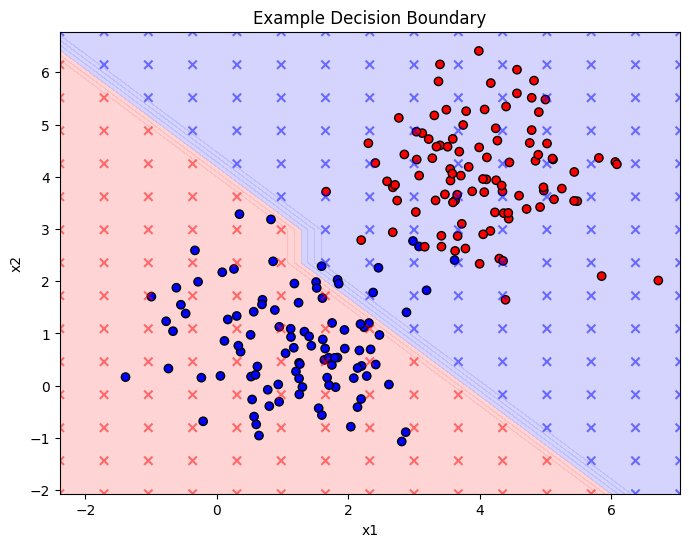

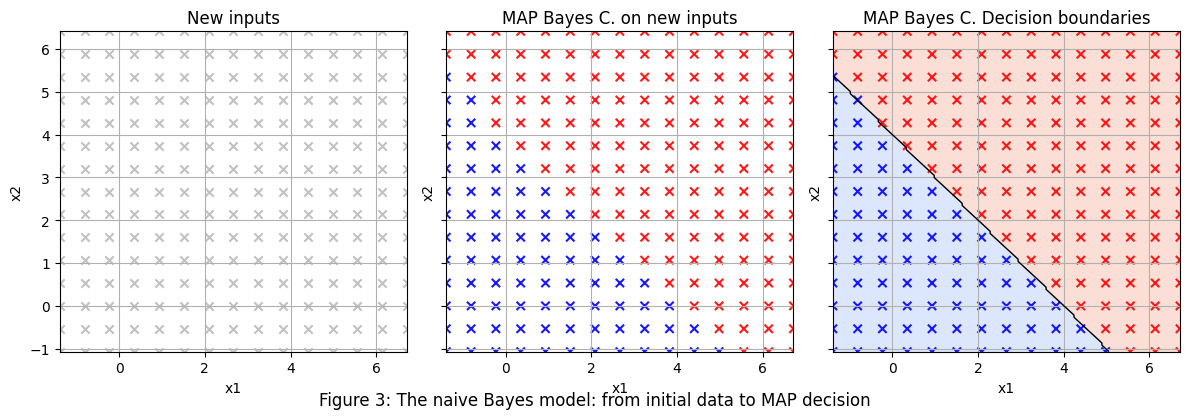

In [42]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def simulate_gaussian_2class(N=200, mean1=(1,0), mean2=(1,0), cov1=np.array([[1, 0], [0, 1]]), cov2=np.array([[1, 0], [0, 1]])):
    """
Génère un dataset 2D binaire de taille N (2 classes) :
    - Classe 0 : N(mu1, cov1^2 I)
    - Classe 1 : N(mu2, sigma^2 I)
    Retourne X (N,2) et Y (N,)
    """
    N1 = N // 2
    N2 = N - N1

    x1 = np.random.multivariate_normal(mean1, cov1, N1)
    y1 = np.ones(N1)
    x2 = np.random.multivariate_normal(mean2, cov2, N2)
    y2 = np.zeros(N2)

    X = np.vstack((x1, x2))
    Y = np.hstack((y1, y2))
    return X, Y


def grid_evaluation(X, Neval):
    x1, x2= X[:,0], X[:,1]
    x1_min,x1_max = min(x1)-1,max(x1)+1
    x2_min,x2_max = min(x2)-1,max(x2)+1
    h1, h2= (x1_max-x1_min)/Neval, (x2_max-x2_min)/Neval
    x1Grid,x2Grid=np.meshgrid(np.arange(x1_min,x1_max,h1),np.arange(x2_min,x2_max,h2))
    return x1Grid, x2Grid

def plot_decision_boundary(X, Y, model, Neval=100, title="Decision Boundary"):
    x1Grid, x2Grid = grid_evaluation(X, Neval)
    grid_points = np.c_[x1Grid.ravel(), x2Grid.ravel()]
    Z = np.array([model(point) for point in grid_points])
    Z = Z.reshape(x1Grid.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_points = ListedColormap(['r', 'b'])
    plt.figure(figsize=(8,6))
    plt.contourf(x1Grid, x2Grid, Z, alpha=0.5, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolor='k', marker='o', cmap=cmap_points)
    plt.scatter(grid_points[:,0], grid_points[:,1], c=Z.ravel(), marker="x", alpha=0.5, cmap=cmap_points)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def plot_nb_map_figure(X, model, Neval=15, nx=150, ny=150,
                       suptitle="Figure 3: The naive Bayes model: from initial data to MAP decision"):
    """
    X      : données (n, 2)
    model  : fonction de prédiction binaire, ex. posterior_prob(x) -> 0 ou 1
    Neval  : taille de la petite grille de 'new_inputs'
    nx, ny : résolution de la grille dense pour la frontière
    """

    x1 = X[:, 0]
    x2 = X[:, 1]
    x1_min, x1_max = x1.min(), x1.max()
    x2_min, x2_max = x2.min(), x2.max()

    gx, gy = np.meshgrid(
        np.linspace(x1_min, x1_max, Neval),
        np.linspace(x2_min, x2_max, Neval)
    )
    new_inputs = np.c_[gx.ravel(), gy.ravel()]  # (Neval*Neval, 2)
    new_preds  = np.array([model(x) for x in new_inputs])  # 0/1

    # --- Grille dense pour visualiser la frontière ---
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, nx),
        np.linspace(x2_min, x2_max, ny)
    )
    grid_pts = np.c_[xx1.ravel(), xx2.ravel()]
    Z = np.array([model(x) for x in grid_pts]).reshape(xx1.shape)  # 0/1

    fig, axs = plt.subplots(1, 3, figsize=(12, 4.5), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.25)

    # (a) New inputs (gris)
    axs[0].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.6, c="0.6")
    axs[0].set_title("New inputs")
    axs[0].set_xlabel("x1")
    axs[0].set_ylabel("x2")
    axs[0].set_xlim(x1_min, x1_max)
    axs[0].set_ylim(x2_min, x2_max)
    axs[0].grid(True)
    axs[0].set_aspect("equal", adjustable="box")

    # (b) MAP Bayes classifier on new inputs (rouge/bleu)
    colors = np.where(new_preds == 1, "red", "blue")
    axs[1].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.9, c=colors)
    axs[1].set_title("MAP Bayes C. on new inputs")
    axs[1].set_xlabel("x1")
    axs[1].set_ylabel("x2")
    axs[1].grid(True)
    axs[1].set_aspect("equal", adjustable="box")

    # (c) Decision boundaries + points colorés
    axs[2].contourf(xx1, xx2, Z,
                    levels=[-0.5, 0.5, 1.5], alpha=0.3, cmap="coolwarm")
    axs[2].contour(xx1, xx2, Z,
                   levels=[0.5], colors="k", linewidths=1.0)  # frontière
    axs[2].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.9, c=colors)
    axs[2].set_title("MAP Bayes C. Decision boundaries")
    axs[2].set_xlabel("x1")
    axs[2].set_ylabel("x2")
    axs[2].grid(True)
    axs[2].set_aspect("equal", adjustable="box")

    plt.suptitle(suptitle, y=0.02)
    plt.tight_layout()
    plt.show()


# Exemple :
X, Y = simulate_gaussian_2class(N=200, mean1=(1,1), mean2=(4,4))
x1Grid, x2Grid = grid_evaluation(X, Neval=15)
plot_decision_boundary(X, Y, lambda x: 1 if x[0] + x[1] > 4 else 0, Neval=15, title="Example Decision Boundary")
plot_nb_map_figure(X, lambda x: 1 if x[0] + x[1] > 4 else 0, Neval=15, nx=150, ny=150)

## Classification Decision Tree

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text

# 1) Entraîner un arbre
def fit_decision_tree(X, Y, **tree_params):
    """
    Entraîne un DecisionTreeClassifier sur (X,Y).
    Exemple d'usage des params:
      criterion='gini'|'entropy', max_depth=None, min_samples_split=20, min_samples_leaf=10, random_state=0, ...
    """
    clf = DecisionTreeClassifier(**tree_params)
    clf.fit(X, Y)
    return clf

# 2) Affichage texte de l'arbre (optionnel)
def print_tree_text(model, feature_names=("x1","x2")):
    print(export_text(model, feature_names=list(feature_names)))


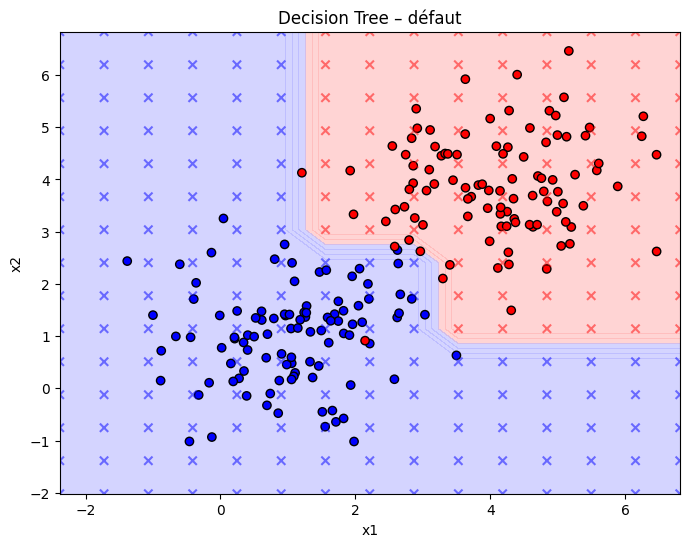

Accuracy (train) = 1.000
|--- x2 <= 2.60
|   |--- x1 <= 3.16
|   |   |--- x1 <= 2.12
|   |   |   |--- class: 1.0
|   |   |--- x1 >  2.12
|   |   |   |--- x1 <= 2.17
|   |   |   |   |--- class: 0.0
|   |   |   |--- x1 >  2.17
|   |   |   |   |--- class: 1.0
|   |--- x1 >  3.16
|   |   |--- x2 <= 1.06
|   |   |   |--- class: 1.0
|   |   |--- x2 >  1.06
|   |   |   |--- class: 0.0
|--- x2 >  2.60
|   |--- x1 <= 1.08
|   |   |--- class: 1.0
|   |--- x1 >  1.08
|   |   |--- x2 <= 2.68
|   |   |   |--- x1 <= 2.79
|   |   |   |   |--- class: 1.0
|   |   |   |--- x1 >  2.79
|   |   |   |   |--- class: 0.0
|   |   |--- x2 >  2.68
|   |   |   |--- class: 0.0



In [32]:
# 0) Données + grille
X, Y = simulate_gaussian_2class(N=200, mean1=(1,1), mean2=(4,4))
x1Grid, x2Grid = grid_evaluation(X, Neval=15)

# 1) Entraînement (params par défaut)
tree = fit_decision_tree(X, Y, random_state=0)

# 2) Frontières
plot_decision_boundary(X, Y, lambda x: tree.predict([x])[0], Neval=15, title="Decision Tree – défaut")

# 3) Score (train) et structure
train_acc = tree.score(X, Y)
print(f"Accuracy (train) = {train_acc:.3f}")
print_tree_text(tree, feature_names=("x1","x2"))


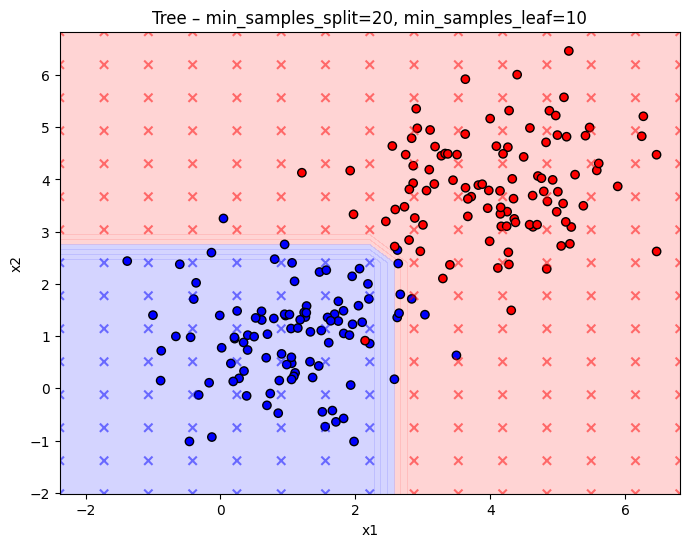

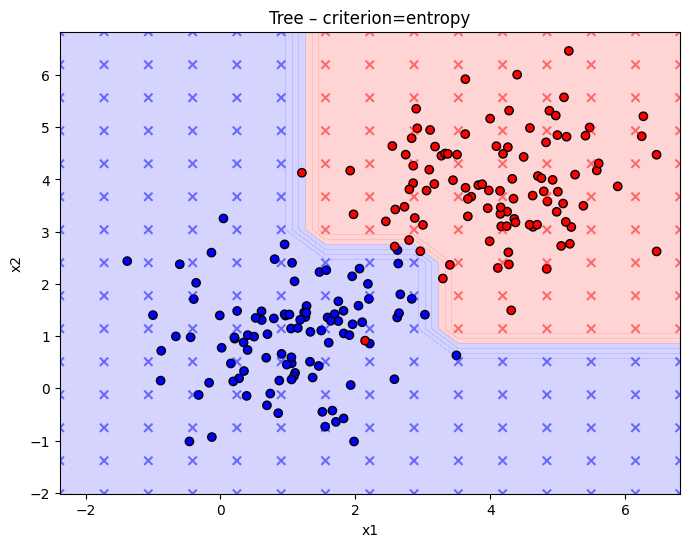

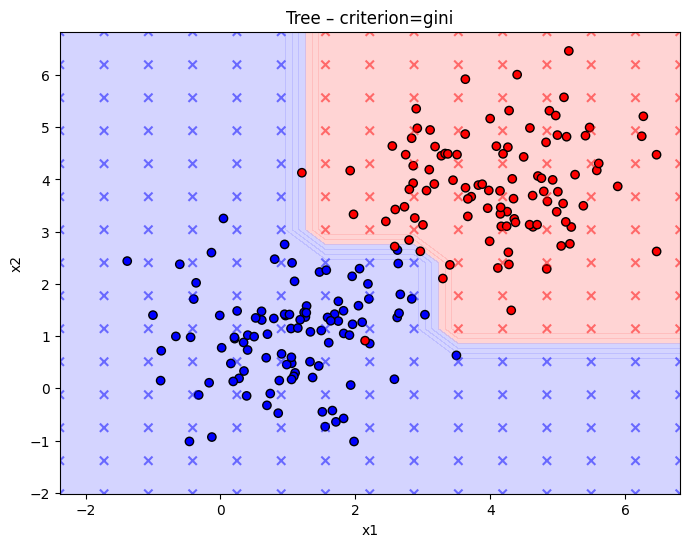

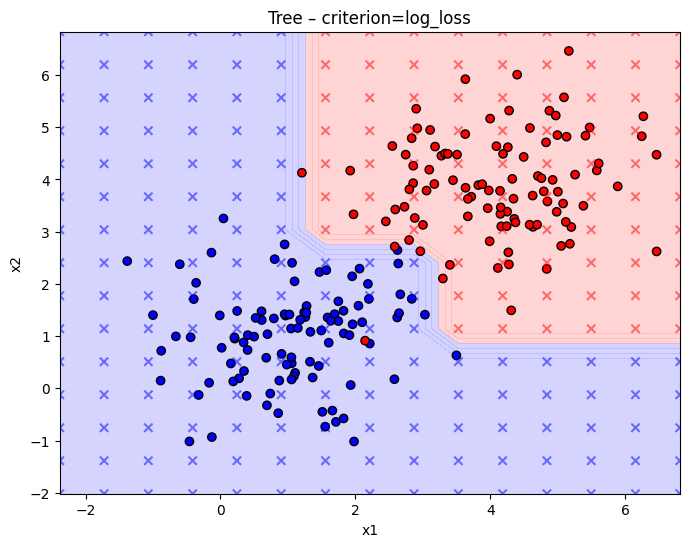

In [33]:
# (A) Contraindre l’arbre (réduit overfit)
from matplotlib.pyplot import plot


tree_tuned = fit_decision_tree( X, Y, min_samples_split=20, min_samples_leaf=10, random_state=0)
plot_decision_boundary(X, Y, lambda x: tree_tuned.predict([x])[0], Neval=15, title="Tree – min_samples_split=20, min_samples_leaf=10")

# Changer la "deviance" (critère)
tree_entropy = fit_decision_tree(X, Y, criterion="entropy", random_state=0)
plot_decision_boundary(X, Y, lambda x: tree_entropy.predict([x])[0], Neval=15, title="Tree – criterion=entropy")

# Changer la "deviance" (critère)
tree_gini = fit_decision_tree(X, Y, criterion="gini", random_state=0)
plot_decision_boundary(X, Y, lambda x: tree_gini.predict([x])[0], Neval=15, title="Tree – criterion=gini")

# Changer la "deviance" (critère)
tree_log_loss = fit_decision_tree(X, Y, criterion="log_loss", random_state=0)
plot_decision_boundary(X, Y, lambda x: tree_log_loss.predict([x])[0], Neval=15, title="Tree – criterion=log_loss")


## Comment suggérer de tuner ces hyperparamètres ?

Idée générale (liée au compromis biais-variance et à l’overfitting des arbres profonds ) :

Commencer avec des valeurs plutôt restrictives (par ex. min_samples_leaf entre 5 et 20, max_depth modérée) pour éviter les arbres trop profonds et très variables.

Faire de la validation croisée (ou utiliser un set de validation) pour choisir les hyperparamètres qui minimisent l’erreur de généralisation (ou maximisent accuracy / AUC, etc.).

Typiquement :

- si le modèle overfit (erreur train très faible mais test beaucoup plus haute) → augmenter min_samples_split, min_samples_leaf, réduire max_depth.

- si le modèle underfit (erreur élevée partout) → réduire un peu ces contraintes (feuilles plus petites, profondeur plus grande).

## Bagging

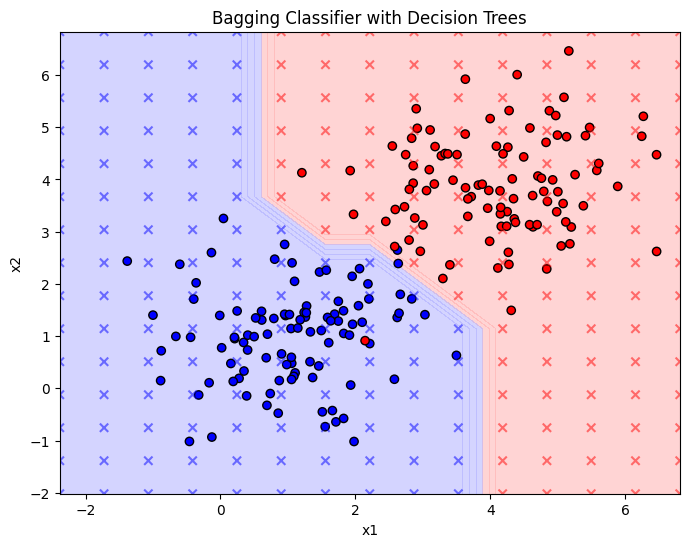

In [36]:
from sklearn.ensemble import BaggingClassifier

base_tree = DecisionTreeClassifier(criterion="gini", random_state=0)

bag = BaggingClassifier(
    estimator=base_tree,      # ou base_estimator dans certaines versions de sklearn
    n_estimators=50,          # nombre d’arbres
    max_samples=1.0,          # fraction d’échantillons par bootstrap
    max_features=1.0,         # fraction de features utilisées par arbre
    bootstrap=True,           # échantillons bootstrapés
    bootstrap_features=False,
    random_state=0
)

treemodfit = base_tree.fit(X, Y)
bagmodfit = bag.fit(X, Y)
pY_train = bagmodfit.predict_proba(X)

plot_decision_boundary(X, Y, lambda x: bagmodfit.predict([x])[0], Neval=15, title="Bagging Classifier with Decision Trees")

## Meta-paramètres importants de Bagging

Pour BaggingClassifier :

- estimator : le modèle de base (ici un arbre de décision).

- n_estimators : nombre de modèles de base (arbres) dans l’ensemble.

- max_samples : proportion (ou nb) d’observations utilisées pour entraîner chaque arbre.

- max_features : proportion (ou nb) de variables utilisées par arbre.

- bootstrap : échantillonnage avec remise sur les observations.

- bootstrap_features : idem pour les features.

- oob_score : si True, calcule le score Out-Of-Bag (très utile pour estimer la généralisation sans CV).

Jouer sur n_estimators, max_samples, bootstrap et regarder l’effet sur la frontière : plus d’arbres → variance réduite, frontières plus lisses.

## Random Forest

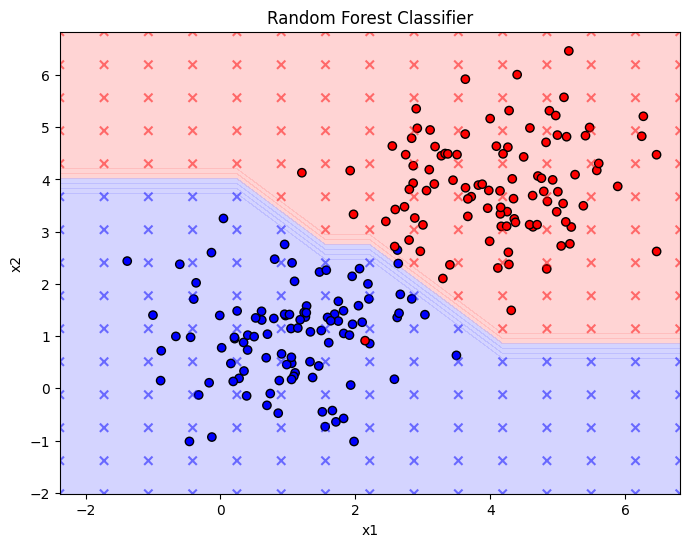

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=0)
rf.fit(X, Y)
pY_train = rf.predict_proba(X)

plot_decision_boundary(X, Y, lambda x: rf.predict([x])[0], Neval=15, title="Random Forest Classifier")


## Meta-paramètres d’un RandomForestClassifier

Les hyperparamètres clés :

- n_estimators : nombre d’arbres dans la forêt.

- max_depth : profondeur max des arbres.

- min_samples_split, min_samples_leaf : comme pour un arbre simple.

- max_features : nb de variables testées à chaque split (contrôle la décorrélation des arbres)

    - Classification : souvent sqrt(p) ou p/3 comme indiqué dans le cours.

- bootstrap : par défaut True.

-oob_score : si True, calcule l’Out-Of-Bag score (approx erreur de généralisation).

L’idée : Bagging + randomisation des variables → arbres moins corrélés → meilleure réduction de variance à l’agrégation.

Score train : 1.0
OOB score   : 0.965
Importances : [0.48533373 0.51466627]


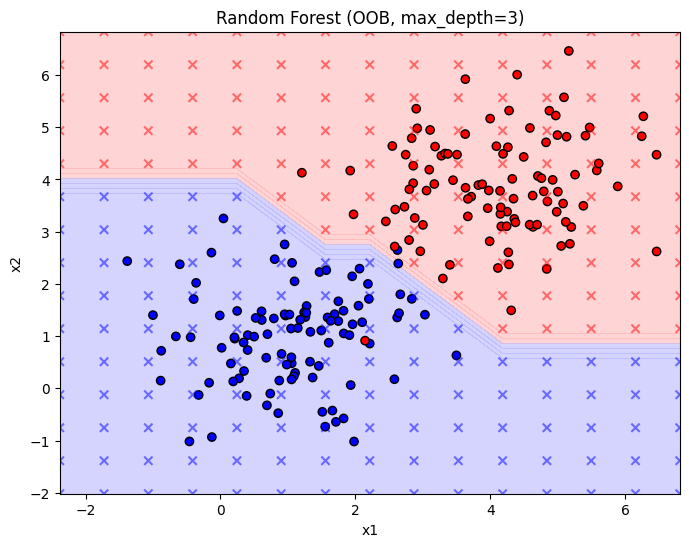

In [40]:
RF2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0, oob_score=True)
RF2_fit = RF2.fit(X, Y)

print("Score train :", RF2.score(X, Y))
print("OOB score   :", RF2.oob_score_)
print("Importances :", RF2.feature_importances_)

plot_decision_boundary(X, Y, lambda x: RF2.predict([x])[0], Neval=15, title="Random Forest (OOB, max_depth=3)")

**oob_score_** ≈ score sur des pseudo-données de test (sorties des bootstrap où un point donné n’était pas sélectionné).

**feature_importances_** : importance de chaque variable, basée sur la diminution moyenne de l’impureté (Gini / entropie) à chaque split.

## Extra Trees

Score train ExtraTrees : 1.0
OOB score ExtraTrees   : 0.98
Importances ExtraTrees : [0.49051075 0.50948925]


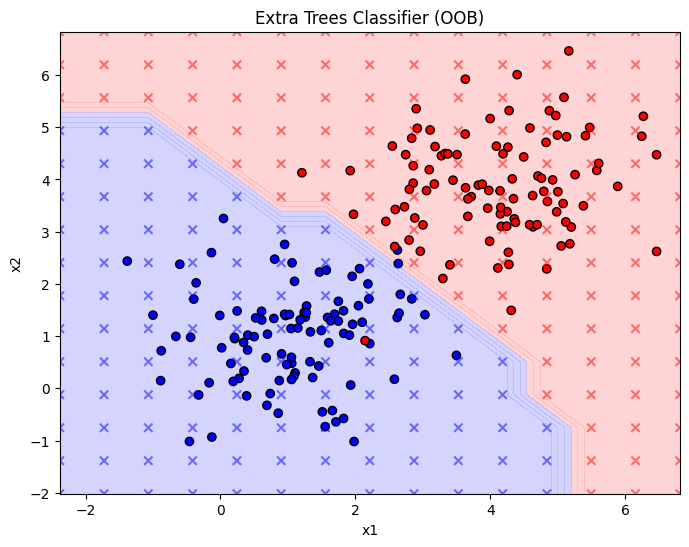

In [41]:
from sklearn.ensemble import ExtraTreesClassifier

ExTC = ExtraTreesClassifier(n_estimators=200, max_depth=None, random_state=0, bootstrap=True, oob_score=True)
ExTC_fit = ExTC.fit(X, Y)

print("Score train ExtraTrees :", ExTC.score(X, Y))
print("OOB score ExtraTrees   :", ExTC.oob_score_)
print("Importances ExtraTrees :", ExTC.feature_importances_)

plot_decision_boundary(X, Y, lambda x: ExTC.predict([x])[0], Neval=15, title="Extra Trees Classifier (OOB)")

### Différences essentielles vs Random Forest

#### Random Forest :

Bootstrap sur les observations.

- Pour chaque split, on choisit une sous-liste aléatoire de features, puis la meilleure coupure (seuil) sur ces features.

#### Extra Trees :

Souvent pas de bootstrap (mais on peut l’activer).

Pour chaque split :

- choix aléatoire d’un sous-ensemble de features,

- seuils de coupe tirés aléatoirement dans le range de la feature,

- on choisit le meilleur parmi ces seuils aléatoires (donc moins optimisé que RF).

#### Résultat :

arbres encore plus aléatoires, souvent plus rapides à construire,

parfois un peu plus de biais mais moins de variance → bon pouvoir de généralisation, surtout agrégés.